### Imports 

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from optic.models.tx import pamTransmitter
from optic.models.devices import photodiode, edfa, dac, adc, mzm, basicLaserModel
from optic.dsp.equalization import dfe, ffe
from optic.models.channels import linearFiberChannel, awgn
from optic.comm.sources import bitSource
from optic.comm.modulation import modulateGray, grayMapping , demodulateGray
from optic.comm.metrics import bert, fastBERcalc, theoryBER
from optic.dsp.core import firFilter, pulseShape, upsample, pnorm, anorm, decimate ,signalPower
from optic.utils import parameters, dBm2W, lin2dB
from optic.plot import eyediagram, pconst
from scipy.special import erfc
import optic.comm.modulation as mod
from numpy.random import normal
import pandas as pd
import sys
import os


sys.path.append(os.path.abspath(os.path.join('..')))

In [27]:
from AnalyticalSNR import (
    superGauss,
    SNR_Folding,
    SNR_DFE,
    SNR_FFE,
    calc_S_th,
    calc_S_th_opticompy,
    calc_S_shot,
    calc_S_shot_opticompy,
    calc_S_RIN,
    calc_S_RIN_opticompy,
    calc_S_ADC,
    calc_S_ADC_opticompy,
    calc_S_N,
    calculate_oma_outer,
    get_spectral_snr,
    ber_from_snr_m_pam
)

## Simple IMDD Transceiver Model 

![Texto Alternativo](images/model.png)


Average power of the modulated optical signal [mW]: 0.500 mW
Average power of the modulated optical signal [dBm]: -3.014 dBm


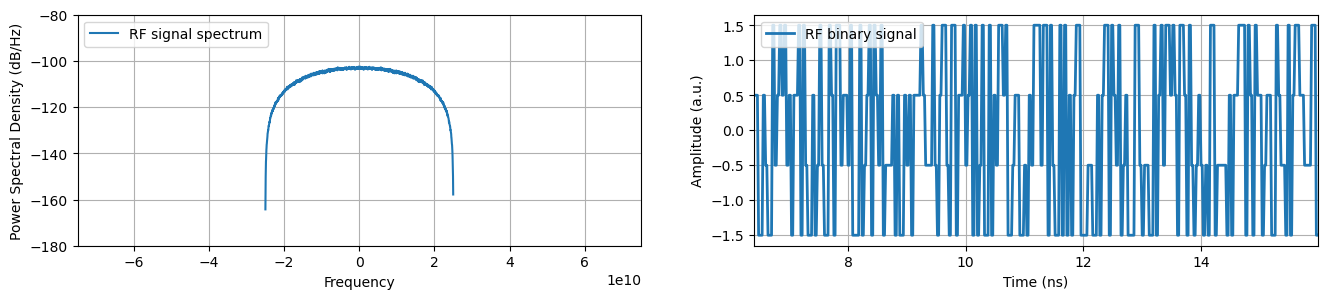

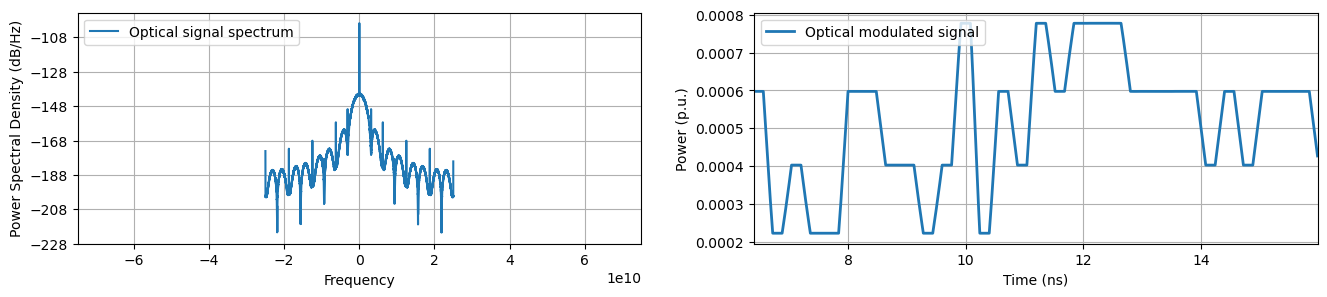

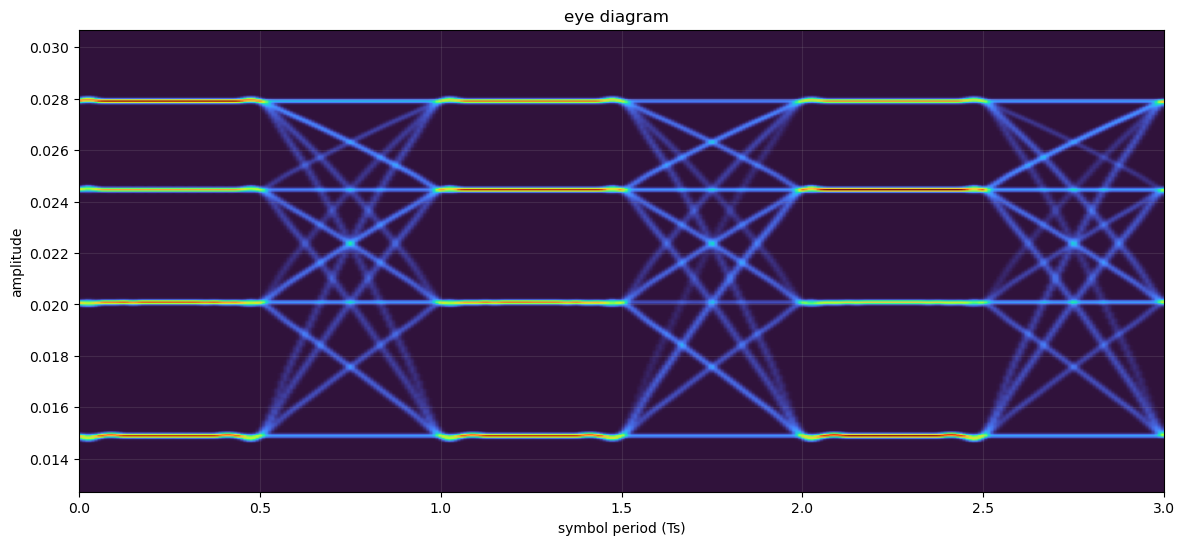

In [28]:
# Rate Sybol
Rs= 25e9

#Sample Per Symbol
SpS= 2

# Sample Rate
Fs= Rs*SpS
n_dac = 8

#Sample Time
Ts= 1/Fs

#Modulation Order
M= 4
Pi_dBm = 0         # laser optical power at the input of the MZM in dBm
Pi = dBm2W(Pi_dBm) # convert from dBm to W

#Parameters for Bits Generation
paramBits =  parameters()
paramBits.nBits = 500000
paramBits.mode= 'random'
paramBits.seed = 7
bits = bitSource(paramBits)

#Parameters for Modulation
symb_Tx= modulateGray(bits, M, 'pam')
symb_Tx_up = upsample(symb_Tx, SpS)

#Parameters for Pulse Shaping
paramPulse = parameters()
paramPulse.pulseType = 'rect'
paramPulse.SpS = SpS
pulse = pulseShape(paramPulse)

#Transmit Signal after Pulse Shaping
signal_Tx = firFilter(pulse, symb_Tx_up)

#DAC Parameters
paramDAC = parameters()
paramDAC.inFs = Fs            # Frequência de entrada (igual a Rs = 25e9)
paramDAC.outFs = n_dac*Fs        # Frequência de saída da simulação (Rs * SpS = 400e9)
paramDAC.nBits = 8         # Resolução nominal alta para emular DAC ideal
paramDAC.ENOB = 8           # Bits efetivos ideais (sem ruído térmico no DAC)
paramDAC.Vpp = 2*np.max(np.abs(signal_Tx))           # Tensão pico a pico elétrica normalizada
paramDAC.AIF = False         # Filtro Anti-Imagem desligado (evita filtro redundante)
signal_Tx_DAC = dac(signal_Tx, paramDAC)
#signal_Tx_DAC = signal_Tx

paramLaser = parameters()
paramLaser.P = Pi_dBm
paramLaser.lw = 0
paramLaser.RIN_var = 1e-14
paramLaser.Fs= paramDAC.outFs
paramLaser.Ns = len(signal_Tx_DAC)
laserTx = basicLaserModel(paramLaser)

paramMZM = parameters()
paramMZM.Vpi = 8
paramMZM.Vb= -paramMZM.Vpi/2

signal_optTx= mzm(laserTx, signal_Tx_DAC, paramMZM)


print('Average power of the modulated optical signal [mW]: %.3f mW'%(signalPower(signal_optTx)/1e-3))
print('Average power of the modulated optical signal [dBm]: %.3f dBm'%(10*np.log10(signalPower(signal_optTx)/1e-3)))


fig, axs = plt.subplots(1, 2, figsize=(16,3))
interval = np.arange(16*20,16*50)
t = interval*Ts/1e-9

# plot psd
axs[0].set_xlim(-3*Rs,3*Rs);
axs[0].set_ylim(-180,-80);
axs[0].psd(signal_Tx,Fs=Fs, NFFT = 2*1024, sides='twosided', label = 'RF signal spectrum')
axs[0].legend(loc='upper left');

axs[1].plot(t, signal_Tx[interval], label = 'RF binary signal', linewidth=2)
axs[1].set_ylabel('Amplitude (a.u.)')
axs[1].set_xlabel('Time (ns)')
axs[1].set_xlim(min(t),max(t))
axs[1].legend(loc='upper left')
axs[1].grid()

fig, axs = plt.subplots(1, 2, figsize=(16,3))
# plot psd
axs[0].set_xlim(-3*Rs,3*Rs);
axs[0].psd(signal_optTx, Fs=Fs, NFFT = 16*1024, sides='twosided', label = 'Optical signal spectrum')
axs[0].legend(loc='upper left');

axs[1].plot(t, np.abs(signal_optTx[interval])**2, label = 'Optical modulated signal', linewidth=2)
axs[1].set_ylabel('Power (p.u.)')
axs[1].set_xlabel('Time (ns)')
axs[1].set_xlim(min(t),max(t))
axs[1].legend(loc='upper left')
axs[1].grid()
plt.rcParams['figure.figsize'] = (14, 6)


eyediagram(np.real(signal_optTx), len(signal_optTx), n_dac*SpS ,ptype = 'fancy')

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def superGauss(f, n, B_3dB):
    '''
    Calculates the supergaussian filter frequency response for a given order n and 3dB bandwidth B_3dB.

    param:
        f (np.array): Frequency array (in Hz) for which to calculate the filter response.
        n (int): Order of the supergaussian filter.
        B_3dB (float): 3dB bandwidth of the filter (in Hz).
    
    return:
        H_sg (np.array): Frequency response of the supergaussian filter at the given frequencies.
    '''

    alpha = np.log(2)/2
    H_sg = np.exp(-alpha * (f / B_3dB)**(2*n))
    return H_sg

4000000


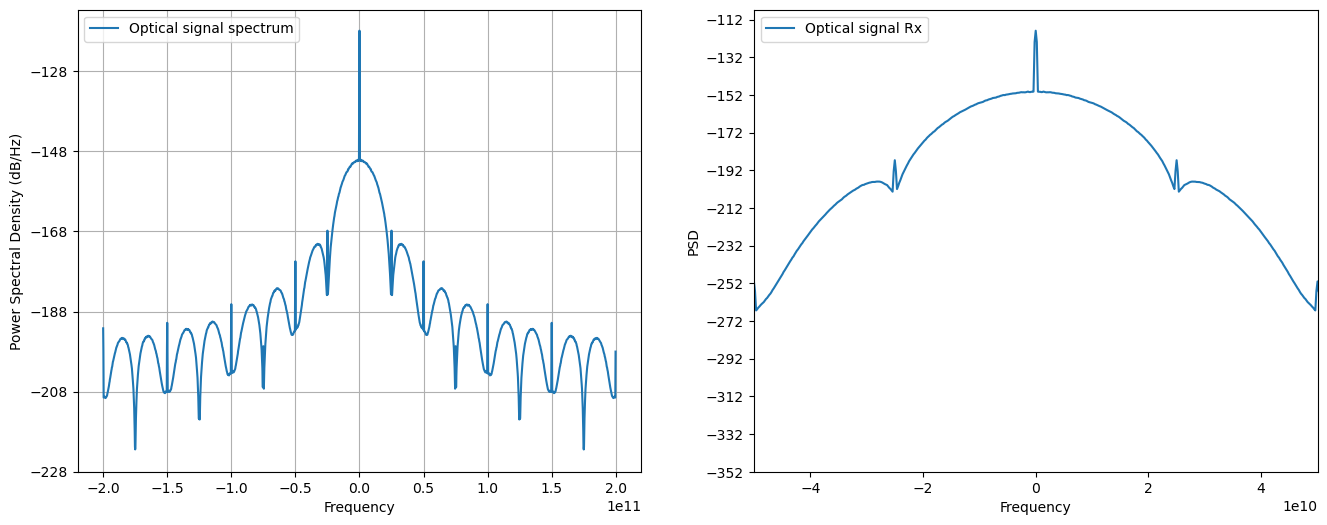

In [30]:
from scipy.fft import fft, ifft, fftfreq


# 1. Definir os parâmetros do canal baseados no artigo
# O artigo varia o B_3dB no eixo X dos gráficos (ex: de 0.1 a 1.5 * Rs)
# e testa a ordem do filtro como 1 e 3.
print(len(signal_optTx))
n_order = 1             # Ordem do supergaussiano (ex: 1 ou 3)
B_3dB = 0.4 * Rs        # Largura de banda em 40% da taxa de símbolos

# 2. Criar o vetor de frequências para o sinal de simulação
N_samples = len(signal_optTx)
sim_Fs = paramDAC.outFs # A taxa de amostragem do sinal modulado (400 GHz)

# Cria o vetor de frequências correspondente aos bins da FFT
f = fftfreq(N_samples, d=1/sim_Fs)

# 3. Gerar a resposta em frequência do canal
H_ch = superGauss(f, n_order, B_3dB)

# 4. Aplicar o filtro ao sinal no domínio da frequência
signal_optTx_fft = np.fft.fft(signal_optTx)
signal_optRx_fft = signal_optTx_fft * H_ch

# Retornar o sinal filtrado para o domínio do tempo
signal_optRx = ifft(signal_optRx_fft)

fig, axs = plt.subplots(1, 2, figsize=(16,6))
# plot psd
axs[0].psd(signal_optTx, Fs=paramDAC.outFs, NFFT = 2048, sides='twosided', label = 'Optical signal spectrum')
axs[0].legend(loc='upper left');

axs[1].psd(signal_optRx, Fs = paramDAC.outFs, NFFT = 2048, sides = 'twosided', label = "Optical signal Rx")
axs[1].set_ylabel('PSD')
axs[1].set_xlabel('Frequency')
axs[1].legend(loc='upper left')
axs[1].grid()
axs[1].set_xlim(-0.5e11, 0.5e11)
plt.rcParams['figure.figsize'] = (14, 6)



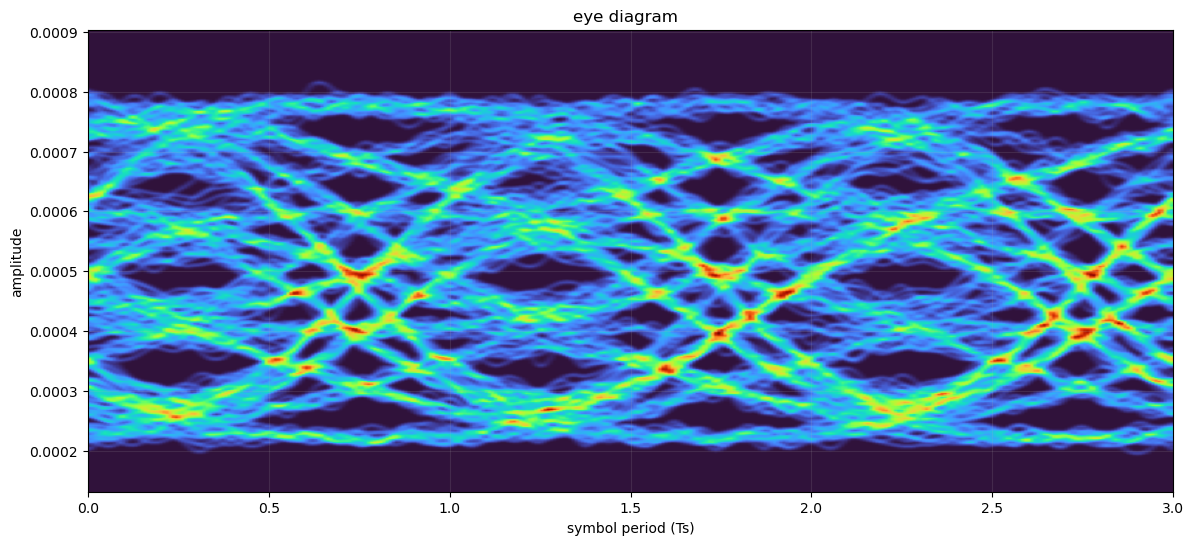

<function matplotlib.pyplot.show(close=None, block=None)>

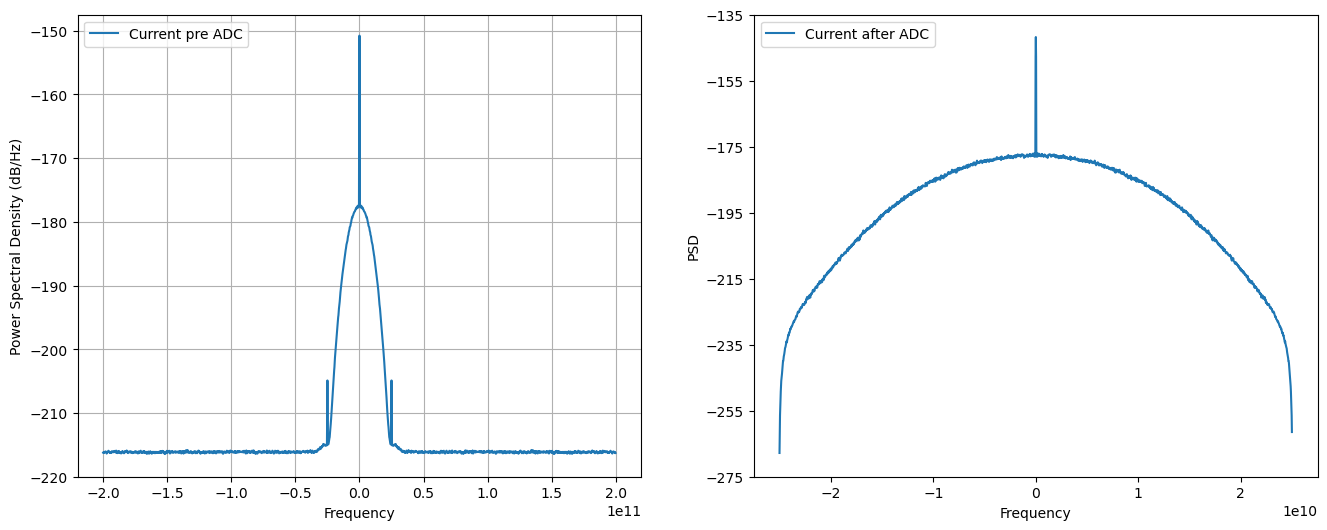

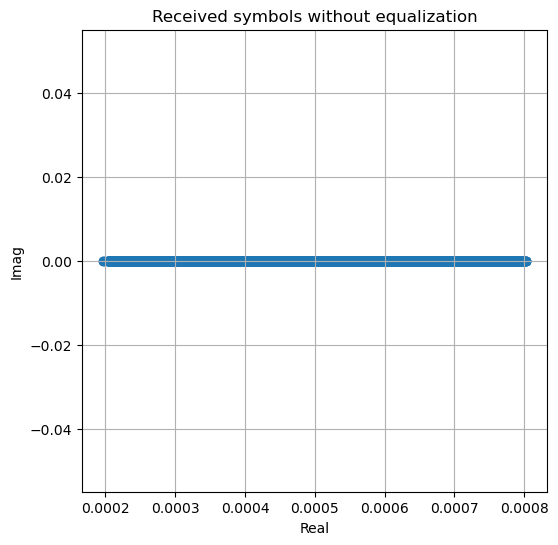

In [31]:
paramPD = parameters()
paramPD = parameters()
paramPD.R = 1.0                           # Responsividade de 1 A/W (Tabela I do artigo)
paramPD.Tc = 25                           # Não utilizado (o artigo fixa a PSD do ruído térmico)
paramPD.Id = 10e-9                             # Corrente de escuro zero (omitida no modelo matemático)
paramPD.Ipd_sat = 5e-3                    # Irrelevante (saturação desligada)
paramPD.RL = 50                           # Irrelevante (ruído térmico fixado externamente)
paramPD.B = 30e9                          # Irrelevante (limitação de banda desligada aqui)
paramPD.Fs = paramDAC.outFs               # Frequência de amostragem global da simulação
paramPD.fType = 'rect'                    # Irrelevante
paramPD.PDN = 255                         # Irrelevante
paramPD.ideal = False                     # False para permitir a injeção de ruídos
paramPD.shotNoise = True                  # O modelo do artigo analisa o Shot Noise
paramPD.thermalNoise = True               # O modelo do artigo analisa o Ruído Térmico
paramPD.currentSaturation = False         # O modelo assume um receptor estritamente linear
paramPD.bandwidthLimitation = False       # IMPORTANTE: Desligado (veja explicação abaixo)
paramPD.seed = 7                          # Qualquer número inteiro

PD_signalRx= photodiode(signal_optRx, paramPD)

eyediagram(np.real(PD_signalRx), len(PD_signalRx), n_dac*SpS ,ptype = 'fancy', plotlabel = "" \
"")
#plt.psd(PD_signalRx, NFFT = 1024, Fs = paramDAC.outFs, sides = 'twosided')

paramAdc = parameters()
paramAdc.inFs = paramDAC.outFs
paramAdc.outFs = Fs
paramAdc.Nbits = paramDAC.nBits
paramAdc.ENOB = paramDAC.ENOB
paramAdc.Vmax = np.max(np.abs(PD_signalRx))
paramAdc.Vmin = -paramAdc.Vmax
paramAdc.AAF = False

sigRx = adc(PD_signalRx, paramAdc)
sigRx = firFilter(pulse, sigRx)

fig, axs = plt.subplots(1, 2, figsize=(16,6))
# plot psd
axs[0].psd(PD_signalRx, Fs=paramDAC.outFs, NFFT = 2048, sides='twosided', label = 'Current pre ADC')
axs[0].legend(loc='upper left');

axs[1].psd(sigRx, Fs = Fs, NFFT = 2048, sides = 'twosided', label = "Current after ADC")
axs[1].set_ylabel('PSD')
axs[1].set_xlabel('Frequency')
axs[1].legend(loc='upper left')
axs[1].grid()
plt.rcParams['figure.figsize'] = (14, 6)

paramDec = parameters()
paramDec.SpSin = SpS
paramDec.SpSout = 1

symbRx_vis = decimate(sigRx, paramDec)

plt.figure(figsize=(6,6))
plt.scatter(np.real(symbRx_vis), np.imag(symbRx_vis))

plt.title("Received symbols without equalization")
plt.xlabel("Real")
plt.ylabel("Imag")
plt.grid(True)
plt.show





Performance results:
------------------------------------
Method      |  BER       |  SNR (dB)
------------------------------------
FFE         |  0.00e+00  |  22.43 
DFE         |  0.00e+00  |  22.95 


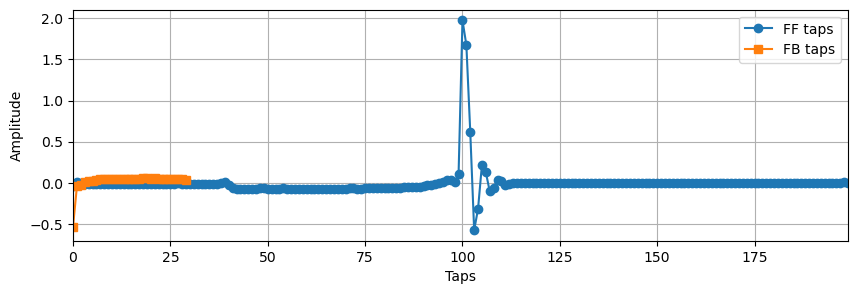

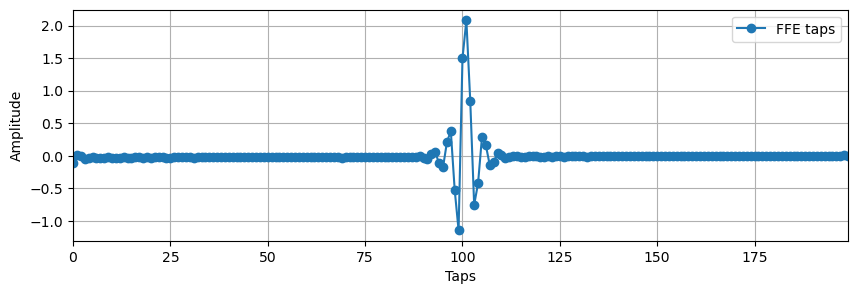

In [32]:
nTrain = 100000  # number of training symbols
plots = True  # enable/disable plots of equalizer taps and MSE convergence
trainingMode = "fulltime"

# Apply DFE equalization
paramDFE = parameters()
paramDFE.nTapsFF = 200
paramDFE.nTapsFB = 30
paramDFE.SpS = SpS
paramDFE.mu = 2e-3
paramDFE.nTrain = nTrain
paramDFE.M = M
paramDFE.trainingMode = trainingMode

outDFE, f, b, mseDFE = dfe(sigRx, symb_Tx, paramDFE)
outDFE = pnorm(outDFE)

if plots:
    plt.figure(figsize=(10,3))
    plt.plot(f, 'o-', label='FF taps')
    plt.plot(b, 's-', label='FB taps')
    plt.xlim(0, max(len(f), len(b))-1)
    plt.xlabel('Taps')
    plt.ylabel('Amplitude')
    plt.grid()
    plt.legend()

# Apply FFE equalization
paramFFE = parameters()
paramFFE.nTaps = 200
paramFFE.mu = 2e-3
paramFFE.nTrain = nTrain
paramFFE.SpS = SpS
paramFFE.M = M
paramFFE.trainingMode = trainingMode

outFFE, h, mseFFE = ffe(sigRx, symb_Tx, paramFFE)
#outFFE = pnorm(outFFE)

if plots:
    plt.figure(figsize=(10,3))
    plt.plot(h, 'o-', label='FFE taps')
    plt.legend()
    plt.xlim(0, len(h)-1)
    plt.xlabel('Taps')
    plt.ylabel('Amplitude')
    plt.grid()

discard = nTrain

# with FFE equalization
ber_ffe, ser_ffe, snr_ffe = fastBERcalc(outFFE[discard:-discard//10], symb_Tx[discard:-discard//10], M, 'pam')

# with DFE equalization
ber_dfe, ser_dfe, snr_dfe = fastBERcalc(outDFE[discard:-discard//10], symb_Tx[discard:-discard//10], M, 'pam')

print('Performance results:')
print('------------------------------------')
print('Method      |  BER       |  SNR (dB)')
print('------------------------------------')
print(f'FFE         |  {ber_ffe[0]:.2e}  |  {snr_ffe[0]:.2f} ')
print(f'DFE         |  {ber_dfe[0]:.2e}  |  {snr_dfe[0]:.2f} ') 

c:\Users\elmer.farias\anaconda3\Lib\site-packages\mpl_scatter_density\scatter_density_axes.py:49: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  self.set_ylim(np.min(y), np.max(y))


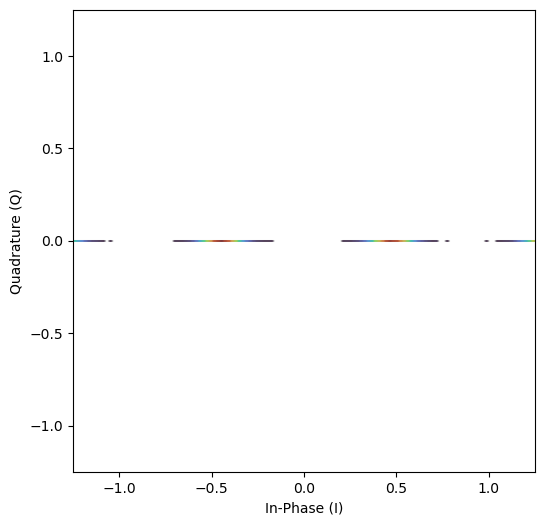

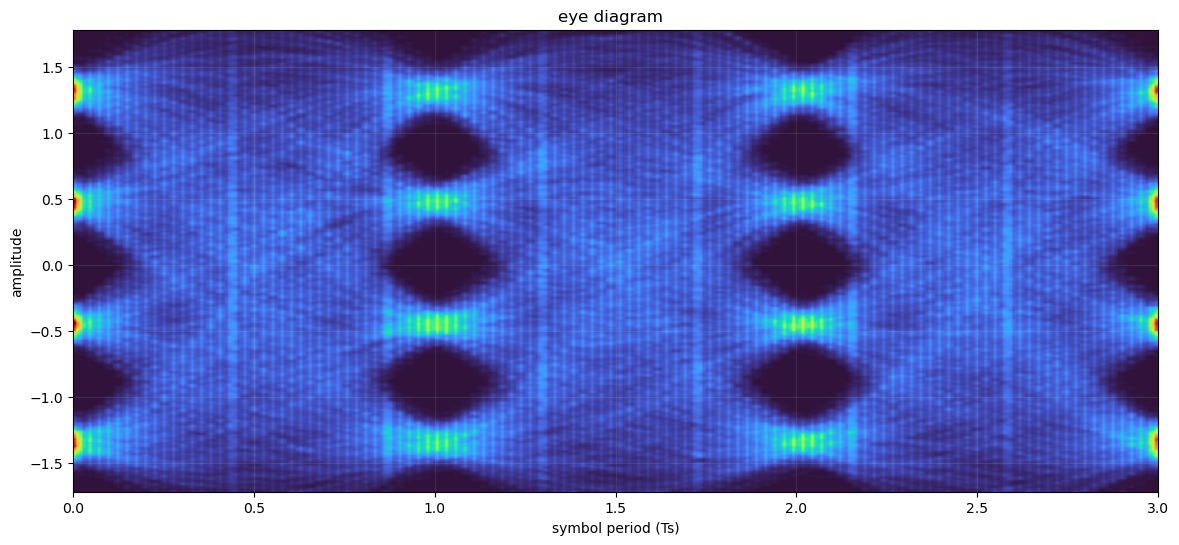

In [33]:
pconst(outFFE[discard:-discard])
eyediagram(outFFE[discard:-discard], len(outFFE)-2*discard, 1, 3, 'fancy')

In [ ]:
# Definindo o vetor de frequências para a análise analítica
N_fft = 2**14
# Usaremos a frequência de amostragem do DAC/Laser para a análise de banda larga
fq_array = np.linspace(-paramDAC.outFs/2, paramDAC.outFs/2, N_fft)

# Parâmetros do Fotodiodo (PIN) e Térmicos
R_pd = paramPD.R         # Responsividade do fotodiodo [A/W] (Exemplo)
Id = paramPD.Id         # Corrente de escuro (Dark Current) [A]
Tc = paramPD.Tc            # Temperatura ambiente [Celsius]
RL = paramPD.RL            # Resistência de carga do receptor [Ohms]

# Parâmetros do ADC (Receptor)
ENOB_rx = paramAdc.ENOB        # Effective Number of Bits do ADC no RX
Vmax_rx = paramAdc.Vmax      # Tensão máxima de clipping do ADC no RX (Exemplo)
Vmin_rx = paramAdc.Vmin     # Tensão mínima de clipping do ADC no RX (Exemplo)

# Potência recebida e Extinction Ratio (estimados do seu sinal simulado)
# Para uma análise precisa, P_RX_avg deve incluir as perdas do canal. 
# Aqui assumimos back-to-back (P_tx = P_rx) para simplificar.
P_RX_avg_W = np.mean(np.abs(signal_optTx)**2) 
P_RX_avg_mW = P_RX_avg_W * 1e3
P_RX_avg_dBm = lin2dB(P_RX_avg_W)
P_TX_sq_avg_w= np.mean(signal_optTx**2)
PSD_signalTx= 
# Calculando Extinction Ratio (ER) aproximado a partir dos níveis do sinal PAM4
#P_max = np.max(np.abs(signal_optTx)**2)
#P_min = np.min(np.abs(signal_optTx)**2)
#ER_linear = P_max / P_min if P_min > 0 else 100
ER_dB = 6 #10 * np.log10(ER_linear)
#print (ER_dB)

# 1. Ruído Térmico
S_th = calc_S_th_opticompy(Tc, RL, fq_array)
N0= 2e-19
S_th = calc_S_th(Tc, RL, fq_array)

# 2. Ruído Shot (Granular)
S_shot = calc_S_shot_opticompy(P_RX_avg_W, R_pd, Id, fq_array)
G=F=R=1
S_shot = calc_S_shot(P_RX_avg_W, G, F, R, fq_array)

# 3. Ruído RIN (Relative Intensity Noise)
# Usamos a variância definida no seu laser (paramLaser.RIN_var)
S_RIN = calc_S_RIN_opticompy(paramLaser.RIN_var, paramLaser.Fs, fq_array)
RIN_coeff_dB = -140  # Convertendo a variância RIN para dB
S_RIN = calc_S_RIN(paramLaser.RIN_var, paramLaser.Fs, fq_array)

# 4. Ruído de Quantização do ADC
S_ADC = calc_S_ADC_opticompy(Vmax_rx, Vmin_rx, ENOB_rx, paramDAC.outFs, fq_array)
PAPR= 
sigma_x_sq= np.trapezoid

S_ADC = calc_S_ADC(PAPR, sigma_x_sq, paramDAC.ENOB, paramDAC.outFs, fq_array)

# Resposta do Canal (ex: filtro passa-baixa ou fibra)
# Aqui usamos a sua função superGauss como exemplo para limitar a banda do canal
B_3dB_canal = 0.4*Rs # Largura de banda do canal em Hz
H_ch = superGauss(fq_array, n=1, B_3dB=B_3dB_canal)
H_ch_sqr = np.abs(H_ch)**2  # Magnitude ao quadrado da resposta do canal

# Resposta do Transmissor (assumindo ideal/plano na banda de interesse)
pPulseA = parameters()
pPulseA.SpS = paramPulse.SpS*n_dac
pPulseA.pulseType = paramPulse.pulseType
h_tx = pulseShape(pPulseA)
H_tx = np.fft.fftshift(np.fft.fft(h_tx, n=N_fft))

# Consolida o Ruído Total
S_N_total = calc_S_N(S_RIN, S_shot, S_th, S_ADC, H_ch_sqr)


# Calcula a OMA Externa
oma_outer = calculate_oma_outer(P_RX_avg_mW, ER_dB)

# SNR Espectral Contínua
SNR_f = get_spectral_snr(fq_array, oma_outer, Rs, H_tx, H_ch, S_N_total)

# SNR Folded (Dobramento da banda para a taxa de símbolo Rs)
# mu = 1 significa que ele vai dobrar 1 banda adjacente para dentro
SNR_folded = SNR_Folding(SNR_f, fq_array, mu=1, Rs=Rs)

# SNR após o Equalizador (Escolha DFE ou FFE)
# Exemplo usando FFE (Feed-Forward Equalizer)
SNR_eq_linear = SNR_FFE(SNR_folded, fq_array, Rs)
SNR_eq_dB = 10 * np.log10(SNR_eq_linear)

# Estimativa Teórica da BER para M-PAM (M=4)
BER_teorica = ber_from_snr_m_pam(SNR_eq_linear, M)

print("--- RESULTADOS ANALÍTICOS ---")
print(f"Potência Recebida (Média): {P_RX_avg_dBm:.2f} dBm")
print(f"OMA Outer: {oma_outer:.3f} mW")
print(f"SNR Pós-Equalização (FFE): {SNR_eq_dB:.2f} dB")
print(f"BER Estimada (PAM-{M}): {BER_teorica:.2e}")


5.443680683535695
--- RESULTADOS ANALÍTICOS ---
Potência Recebida (Média): -33.01 dBm
OMA Outer: 0.555 mW
SNR Pós-Equalização (FFE): 95.47 dB
BER Estimada (PAM-4): 0.00e+00
